In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from dataclasses import dataclass
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from shapely.geometry import box


In [9]:
class Dataset_preparation:
    def __init__(self):
        self.scaler = MinMaxScaler()
        
    def prepare_train_test_data(self, data, target_column='OND_SUM', lookback=8, split_year=2010):
        """Create training and testing sets with a sliding window approach for each location."""
        X, y, y_meta = [], [], []
        
        # Normalize the target column first
        data[f'{target_column}_norm'] = self.scaler.fit_transform(data[[target_column]])

        grouped = data.groupby(['LATITUDE', 'LONGITUDE'])
        
        for _, group in grouped:
            series = group[f'{target_column}_norm'].values
            years = group['YEAR'].values
            lats = group['LATITUDE'].values
            lons = group['LONGITUDE'].values
            
            if len(series) <= lookback:
                continue
            
            for i in range(len(series) - lookback):
                X.append(series[i:i+lookback])
                y.append(series[i+lookback])
                y_meta.append({'YEAR': years[i+lookback],
                                 'LATITUDE': lats[i+lookback],
                                 'LONGITUDE': lons[i+lookback]})

        X, y = np.array(X), np.array(y)
        y_meta_df = pd.DataFrame(y_meta)

        # Split based on year from metadata
        train_indices = y_meta_df['YEAR'] <= split_year
        test_indices = y_meta_df['YEAR'] > split_year
        
        x_train, y_train = X[train_indices], y[train_indices]
        x_test, y_test = X[test_indices], y[test_indices]
        y_test_meta = y_meta_df[test_indices].reset_index(drop=True)
        
        return x_train, x_test, y_train, y_test, y_test_meta

    def normalizer_inverse_transform_array(self, data):
        values = data.reshape(-1, 1)
        values_scaled = self.scaler.inverse_transform(values)
        return values_scaled.flatten()


In [10]:

# Models (KNN, ANN, ELM), same as out first implimaentation. presented on the first paper IIT Delhi papr

# ANN Model
@dataclass
class LMConfig:
    damping: float = 1.0
    damping_inc: float = 10.0
    damping_dec: float = 10.0
    max_iters: int = 200
    tol: float = 1e-6
    l2: float = 0.0
    verbose: bool = True
    batch_size: int = 0

class LMTrainer:
    def __init__(self, model: nn.Module, config: LMConfig = LMConfig(), device: str = "cpu"):
        self.model = model.to(device)
        self.cfg = config
        self.device = device

    @torch.no_grad()
    def _pack_params(self) -> torch.Tensor:
        return parameters_to_vector([p for p in self.model.parameters()])

    @torch.no_grad()
    def _unpack_params(self, vec: torch.Tensor):
        vector_to_parameters(vec, [p for p in self.model.parameters()])

    def _compute_residuals(self, X: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        preds = self.model(X).reshape(-1)
        return preds - y

    def _compute_jacobian(self, X: torch.Tensor) -> torch.Tensor:
        params = [p for p in self.model.parameters() if p.requires_grad]
        P = sum(p.numel() for p in params)
        N = X.shape[0]
        J = torch.zeros(N, P, dtype=X.dtype, device=X.device)

        for i in range(N):
            self.model.zero_grad(set_to_none=True)
            out = self.model(X[i:i+1]).reshape(())
            out.backward()
            grads = []
            for p in params:
                g = p.grad if p.grad is not None else torch.zeros_like(p)
                grads.append(g.reshape(-1))
            J[i, :] = torch.cat(grads)
        return J

    def fit(self, X: torch.Tensor, y: torch.Tensor):
        X = X.to(self.device)
        y = y.to(self.device)

        lam = self.cfg.damping
        with torch.no_grad():
            r = self._compute_residuals(X, y)
            loss = 0.5 * (r @ r).item()

        if self.cfg.verbose:
            print(f"[LM] init loss = {loss:.6f}, lambda = {lam}")

        for it in range(1, self.cfg.max_iters + 1):
            J = self._compute_jacobian(X)
            with torch.no_grad():
                r = self._compute_residuals(X, y)
                JTJ = J.T @ J
                if self.cfg.l2 > 0:
                    JTJ = JTJ + self.cfg.l2 * torch.eye(JTJ.shape[0], dtype=JTJ.dtype, device=JTJ.device)
                g = J.T @ r

                A = JTJ + lam * torch.eye(JTJ.shape[0], dtype=JTJ.dtype, device=JTJ.device)
                try:
                    delta = torch.linalg.solve(A, -g)
                except RuntimeError:
                    delta = torch.linalg.lstsq(A, -g.unsqueeze(1)).solution.squeeze(1)

                w_old = self._pack_params().clone()
                add_vector_to_parameters(delta, [p for p in self.model.parameters()])

                r_new = self._compute_residuals(X, y)
                loss_new = 0.5 * (r_new @ r_new).item()

                if loss_new < loss:
                    impr = (loss - loss_new) / max(loss, 1e-12)
                    loss = loss_new
                    lam = max(lam / self.cfg.damping_dec, 1e-12)
                    if self.cfg.verbose:
                        print(f"[LM] iter {it:03d} loss={loss:.6f}  accepted λ={lam:.3e} rel_impr={impr:.3e}")
                    if impr < self.cfg.tol:
                        print("[LM] converged.")
                        break
                else:
                    self._unpack_params(w_old)
                    lam = lam * self.cfg.damping_inc
                    if self.cfg.verbose:
                        print(f"[LM] iter {it:03d} loss={loss:.6f}  rejected λ={lam:.3e}")
        return loss

torch.set_default_dtype(torch.float64)

class RadBas(nn.Module):
    def forward(self, x):
        return torch.exp(-(x ** 2))

class ANN_RadBas(nn.Module):
    def __init__(self, input_size=8):
        super().__init__()
        self.hidden = nn.Linear(input_size, 20, bias=True)
        self.radbas = RadBas()
        self.output = nn.Linear(20, 1, bias=True)
        
    def forward(self, x):
        x = self.hidden(x)
        x = self.radbas(x)
        x = self.output(x)
        return x.squeeze(-1)

def add_vector_to_parameters(vec: torch.Tensor, parameters):
    pointer = 0
    for p in parameters:
        numel = p.numel()
        p.data.add_(vec[pointer:pointer+numel].view_as(p))
        pointer += numel

# ELM Model
class ELMRegressor:
    def __init__(self, n_hidden=15, activation='sigmoid', alpha=1e-3, random_state=None):
        self.n_hidden = n_hidden
        self.activation = activation
        self.alpha = alpha
        self.random_state = np.random.RandomState(random_state)

    def _activate(self, X):
        if self.activation == 'sigmoid':
            return 1 / (1 + np.exp(-X))
        elif self.activation == 'tanh':
            return np.tanh(X)
        elif self.activation == 'relu':
            return np.maximum(0, X)
        else:
            return X

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.W = self.random_state.normal(size=(n_features, self.n_hidden))
        self.b = self.random_state.normal(size=(self.n_hidden,))
        H = self._activate(X @ self.W + self.b)
        I = np.identity(self.n_hidden)
        self.beta = np.linalg.pinv(H.T @ H + self.alpha * I) @ H.T @ y

    def predict(self, X):
        H = self._activate(X @ self.W + self.b)
        return H @ self.beta


In [21]:

# Main execution

import pandas as pd

data = pd.read_csv("data/kerala_ond.csv")

print(data.shape)
print(data.head())
dp = Dataset_preparation() 
# Prepare training and testing data using the new method
x_train, x_test, y_train, y_test, y_test_meta = dp.prepare_train_test_data(data, lookback=8, split_year=2010)
    
print(f"\nTraining data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
    
# Train KNN model
print("\nTraining KNN model...")
knn = KNeighborsRegressor(n_neighbors=5, metric='euclidean', weights="uniform")
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
    
# Train ELM model
print("Training ELM model...")
elm = ELMRegressor(n_hidden=15, activation='sigmoid', random_state=42)
elm.fit(x_train, y_train)
y_pred_elm = elm.predict(x_test)
   
# Train ANN model
print("Training ANN model...")
torch.manual_seed(42)
X_torch = torch.tensor(x_train)
y_torch = torch.tensor(y_train)
    
model_ann = ANN_RadBas(input_size=x_train.shape[1])
cfg = LMConfig(damping=1.0, max_iters=50, verbose=True)
trainer = LMTrainer(model_ann, cfg, device="cpu")
final_loss = trainer.fit(X_torch, y_torch)
print(f"ANN Final loss: {final_loss}")
    
# ANN predictions
with torch.no_grad():
        X_test_torch = torch.tensor(x_test)
        y_pred_ann = model_ann(X_test_torch).numpy()
    
# Inverse transform predictions to original scale
y_true_orig = dp.normalizer_inverse_transform_array(y_test)
y_pred_knn_orig = dp.normalizer_inverse_transform_array(y_pred_knn)
y_pred_elm_orig = dp.normalizer_inverse_transform_array(y_pred_elm)
y_pred_ann_orig = dp.normalizer_inverse_transform_array(y_pred_ann)

# Evaluate models
print("\nModel Performance (on original scale):")
print("=" * 50)
for name, y_pred in [("KNN", y_pred_knn_orig), ("ELM", y_pred_elm_orig), ("ANN", y_pred_ann_orig)]:
        mae = mean_absolute_error(y_true_orig, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred))
        mae_pct = 100 * mae / np.mean(y_true_orig)
        print(f"{name}:")
        print(f"  MAE: {mae:.2f} mm ({mae_pct:.1f}%)")
        print(f"  RMSE: {rmse:.2f} mm")
    
   




(5658, 4)
   LATITUDE  LONGITUDE  YEAR     OND_SUM
0       8.5       77.0  1901  604.170769
1       8.5       77.0  1902  710.412938
2       8.5       77.0  1903  420.602498
3       8.5       77.0  1904  338.656309
4       8.5       77.0  1905  538.451840

Training data shape: (4692, 8)
Test data shape: (598, 8)

Training KNN model...
Training ELM model...
Training ANN model...
[LM] init loss = 289.750978, lambda = 1.0
[LM] iter 001 loss=43.842589  accepted λ=1.000e-01 rel_impr=8.487e-01
[LM] iter 002 loss=43.123265  accepted λ=1.000e-02 rel_impr=1.641e-02
[LM] iter 003 loss=43.123265  rejected λ=1.000e-01
[LM] iter 004 loss=33.447245  accepted λ=1.000e-02 rel_impr=2.244e-01
[LM] iter 005 loss=33.447245  rejected λ=1.000e-01
[LM] iter 006 loss=33.447245  rejected λ=1.000e+00
[LM] iter 007 loss=21.557940  accepted λ=1.000e-01 rel_impr=3.555e-01
[LM] iter 008 loss=21.557940  rejected λ=1.000e+00
[LM] iter 009 loss=21.419648  accepted λ=1.000e-01 rel_impr=6.415e-03
[LM] iter 010 loss=21.4

In [19]:

def visualize_results(test_meta_df, y_true_orig, y_pred_knn, y_pred_elm, y_pred_ann):
    """Create time-series visualizations with correct temporal alignment."""

    plot_df = test_meta_df.copy()

    plot_df['ACTUAL']   = y_true_orig
    plot_df['KNN_PRED'] = y_pred_knn
    plot_df['ELM_PRED'] = y_pred_elm
    plot_df['ANN_PRED'] = y_pred_ann

    # 🔑 Prediction corresponds to YEAR + 1
    plot_df['PRED_YEAR'] = plot_df['YEAR'] - 1

    # ---- Aggregate separately ----
    actual_yearly = (
        plot_df
        .groupby('YEAR')['ACTUAL']
        .mean()
    )

    knn_yearly = (
        plot_df
        .groupby('PRED_YEAR')['KNN_PRED']
        .mean()
    )

    elm_yearly = (
        plot_df
        .groupby('PRED_YEAR')['ELM_PRED']
        .mean()
    )

    ann_yearly = (
        plot_df
        .groupby('PRED_YEAR')['ANN_PRED']
        .mean()
    )

    # ---- Plot ----
    plt.figure(figsize=(14, 6))

    plt.plot(
        actual_yearly.index,
        actual_yearly.values,
        label="Actual",
        marker='o',
        linewidth=2
    )

    plt.plot(
        knn_yearly.index,
        knn_yearly.values,
        label="KNN",
        linestyle='--'
    )

    plt.plot(
        elm_yearly.index,
        elm_yearly.values,
        label="ELM",
        linestyle='-.'
    )

    plt.plot(
        ann_yearly.index,
        ann_yearly.values,
        label="ANN",
        linestyle=':'
    )

    plt.title(
        "All Models: Season Actual vs. Predicted Monsoon Rainfall (OND)",
        fontsize=20
    )
    plt.xlabel("Year", fontsize=20)
    plt.ylabel("Rainfall (mm)", fontsize=20)

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=16)
    plt.xlim(actual_yearly.index.min(), actual_yearly.index.max()-1)

    plt.grid(True)
    plt.tight_layout()
    plt.show()


def visualize_spatial_predictions(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann, kerala_shape):
    """
    Spatial rainfall maps with correct temporal alignment:
    - ACTUAL at YEAR
    - Predictions at YEAR - 1
    """

    results_df = test_meta_df.copy()

    results_df['ACTUAL'] = y_true
    results_df['KNN'] = y_pred_knn
    results_df['ELM'] = y_pred_elm
    results_df['ANN'] = y_pred_ann

    # 🔑 SAME FIX AS TIME-SERIES
    results_df['PRED_YEAR'] = results_df['YEAR'] - 1

    models_actual = ['ACTUAL']
    models_pred   = ['KNN', 'ELM', 'ANN']

    actual_years = sorted(results_df['YEAR'].unique())

    # --- Colormap (unchanged) ---
    base_cmap = plt.get_cmap("RdBu_r")
    blue_part = base_cmap(np.linspace(0.0, 0.40, 128))
    red_part  = base_cmap(np.linspace(0.60, 1.0, 128))
    colors = np.vstack((blue_part, red_part))
    cmap = plt.get_cmap("Spectral_r") 
    # -------------------------------------------------
    # GLOBAL COLOR NORMALIZATION (constant colorbar)
    # -------------------------------------------------
    all_values = np.concatenate([
        results_df[['ACTUAL']].values.flatten(),
        results_df[['KNN']].values.flatten(),
        results_df[['ELM']].values.flatten(),
        results_df[['ANN']].values.flatten()
    ])

    global_vmin = np.nanmin(all_values)
    global_vmax = np.nanmax(all_values)

    norm = Normalize(vmin=global_vmin, vmax=global_vmax)


    for year in actual_years:

        # ACTUAL for this year
        actual_df = results_df[results_df['YEAR'] == year]

        # PREDICTIONS that correspond to this year
        pred_df = results_df[results_df['PRED_YEAR'] == year]

        if actual_df.empty or pred_df.empty:
            continue

        fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)
        fig.suptitle(f"Spatial Rainfall Patterns – OND {year}", fontsize=26)



        # ---- ACTUAL ----
        pivot = actual_df.pivot(index='LATITUDE', columns='LONGITUDE', values='ACTUAL')
        lats = pivot.index.values
        lons = pivot.columns.values
        data = pivot.values

        masked_data = np.full_like(data, np.nan)
        for iy, lat in enumerate(lats):
            for ix, lon in enumerate(lons):
                cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                    masked_data[iy, ix] = data[iy, ix]

        mesh = axes[0].pcolormesh(lons, lats, masked_data, cmap=cmap, norm=norm, shading="auto")
        kerala_shape.boundary.plot(ax=axes[0], color="black", linewidth=1.8)
        axes[0].set_title("ACTUAL", fontsize=22)
        axes[0].set_ylabel("Latitude", fontsize=22)
        axes[0].set_xlabel("Longitude", fontsize=22)
        axes[0].tick_params(axis='x', labelsize=16) 
        axes[0].tick_params(axis='y', labelsize=16) 

        # ---- PREDICTIONS ----
        for i, model in enumerate(models_pred, start=1):
            pivot = pred_df.pivot(index='LATITUDE', columns='LONGITUDE', values=model)
            data = pivot.values

            masked_data = np.full_like(data, np.nan)
            for iy, lat in enumerate(lats):
                for ix, lon in enumerate(lons):
                    cell = box(lon - 0.125, lat - 0.125, lon + 0.125, lat + 0.125)
                    if kerala_shape.geometry.iloc[0].contains(cell.centroid):
                        masked_data[iy, ix] = data[iy, ix]

            axes[i].pcolormesh(lons, lats, masked_data, cmap=cmap, norm=norm, shading="auto")
            kerala_shape.boundary.plot(ax=axes[i], color="black", linewidth=1.8)
            axes[i].set_title(model, fontsize=22)
            axes[i].set_xlabel("Longitude", fontsize=22)
            axes[i].tick_params(axis='x', labelsize=16) 

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=axes,
            fraction=0.025,
            pad=0.04
        )

        cbar.set_label("Rainfall (mm)", fontsize=22)
        cbar.ax.tick_params(labelsize=18)

        cbar.set_label("Rainfall (mm)", fontsize=22)

        plt.subplots_adjust(right=0.85)
        plt.show()


Generating visualizations...


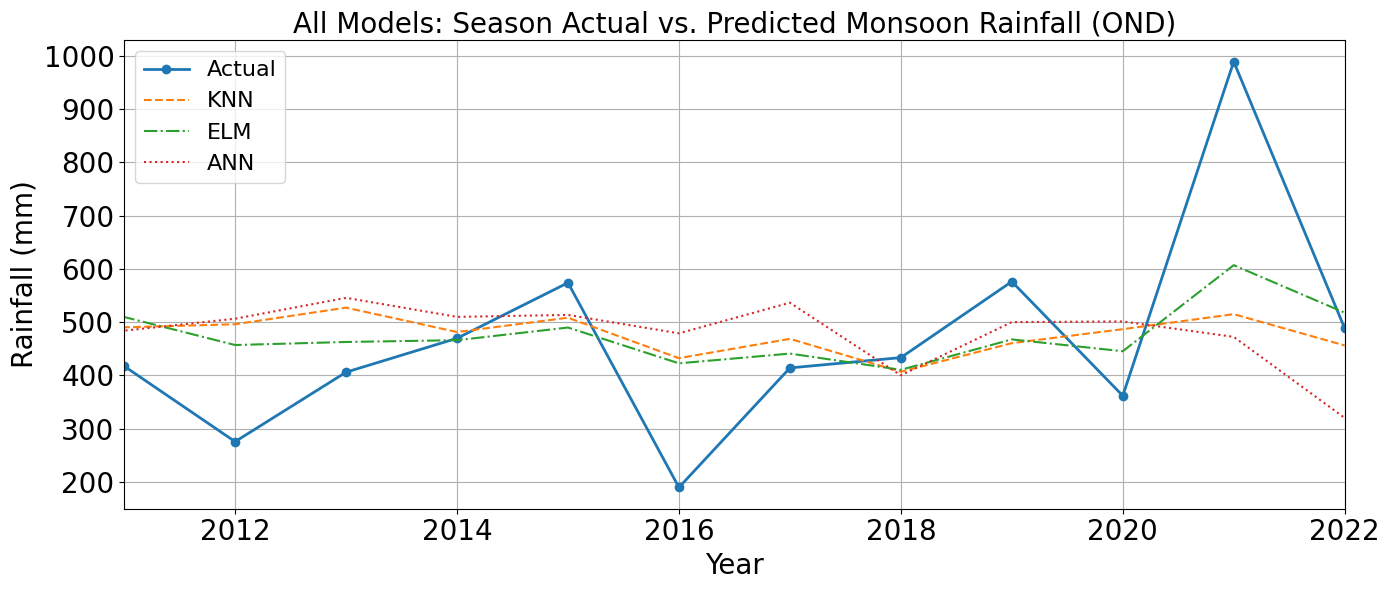

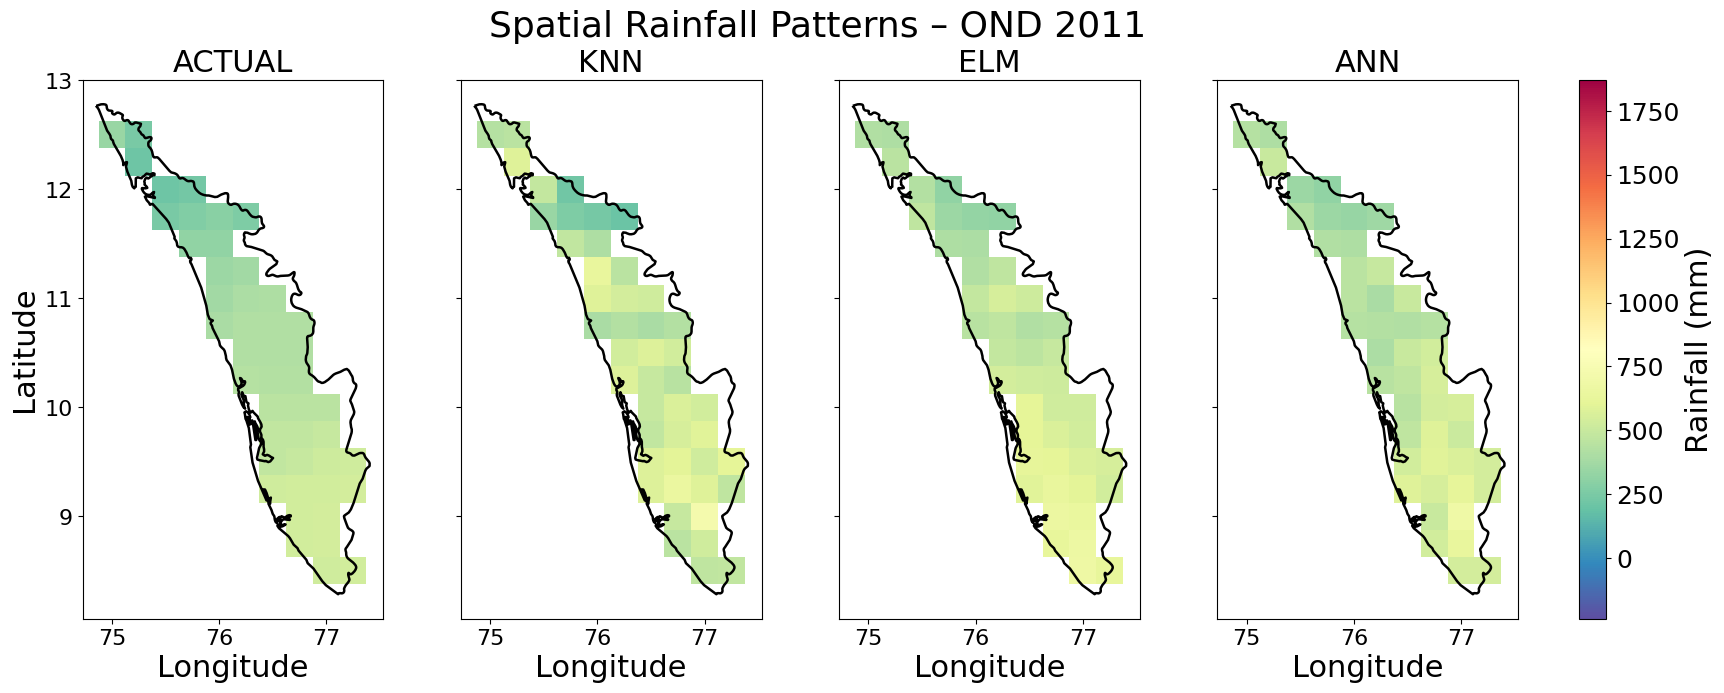

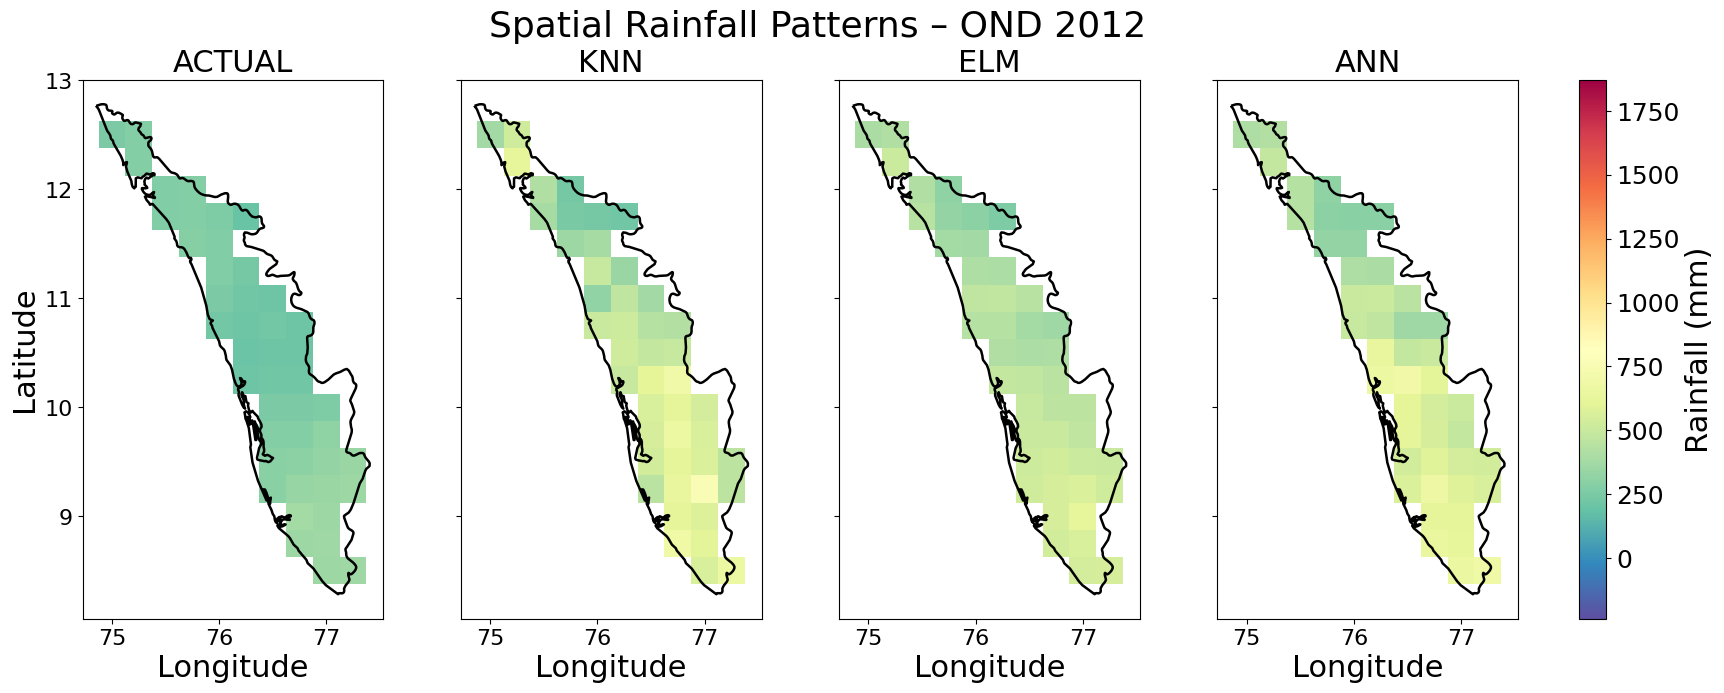

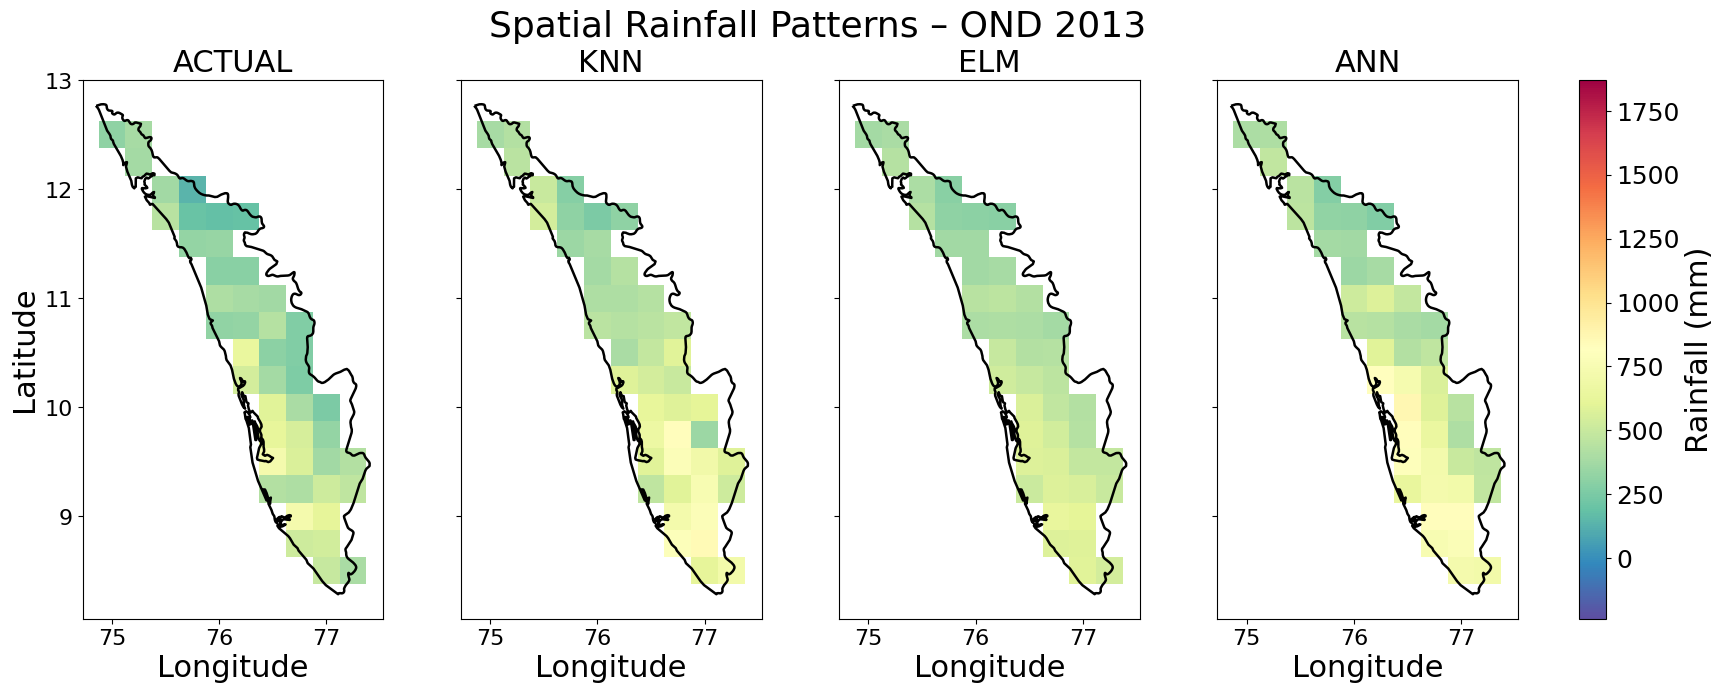

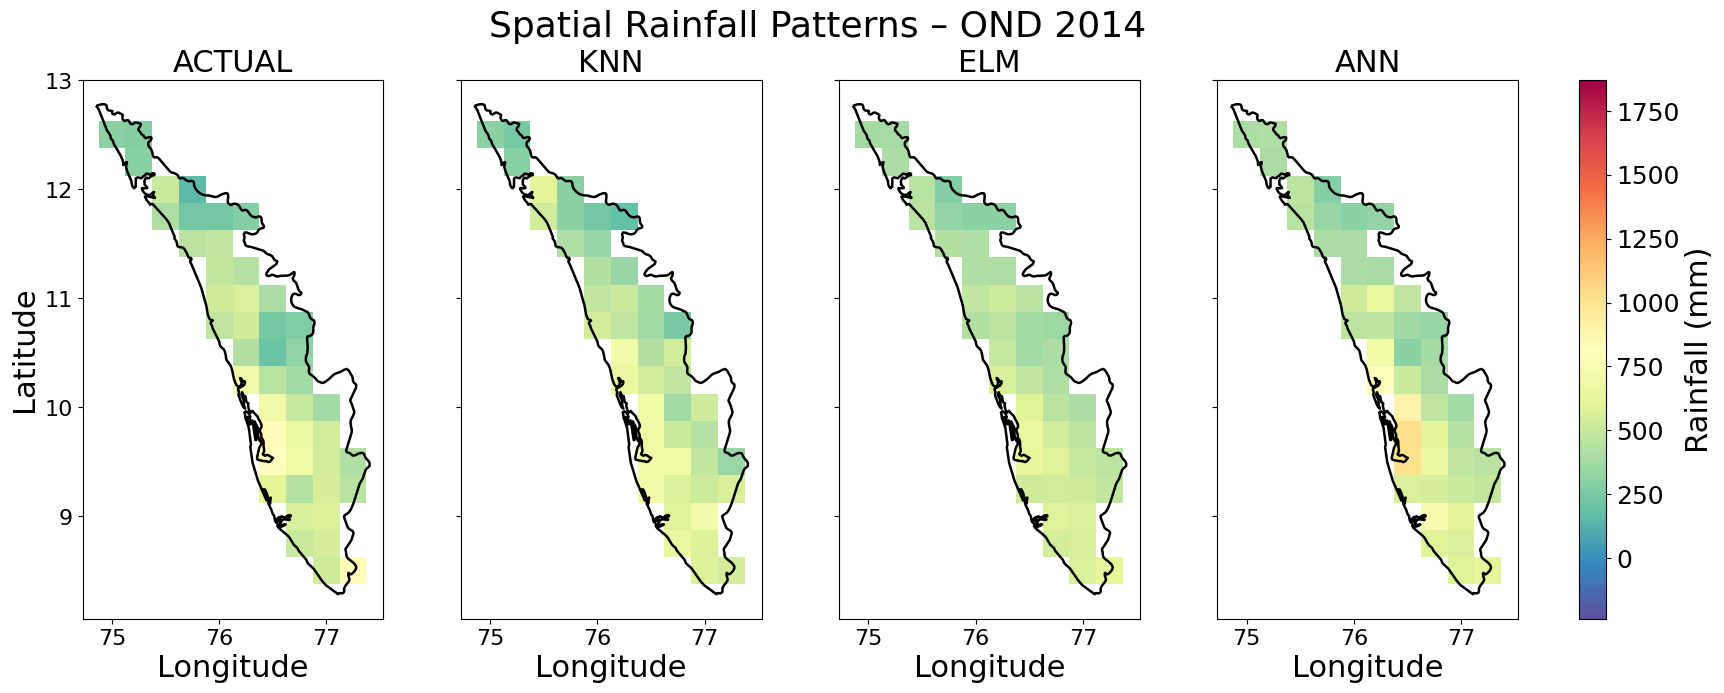

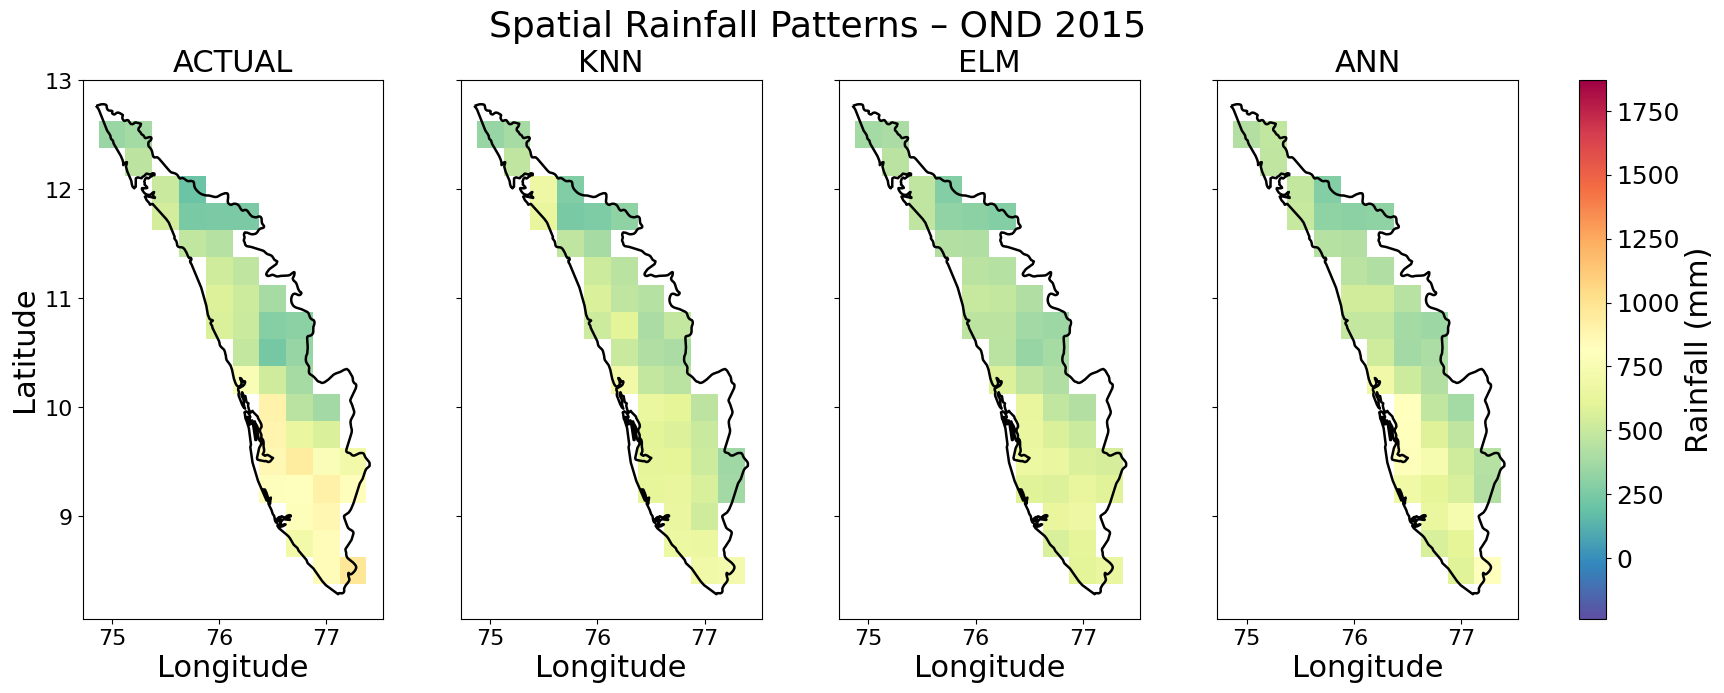

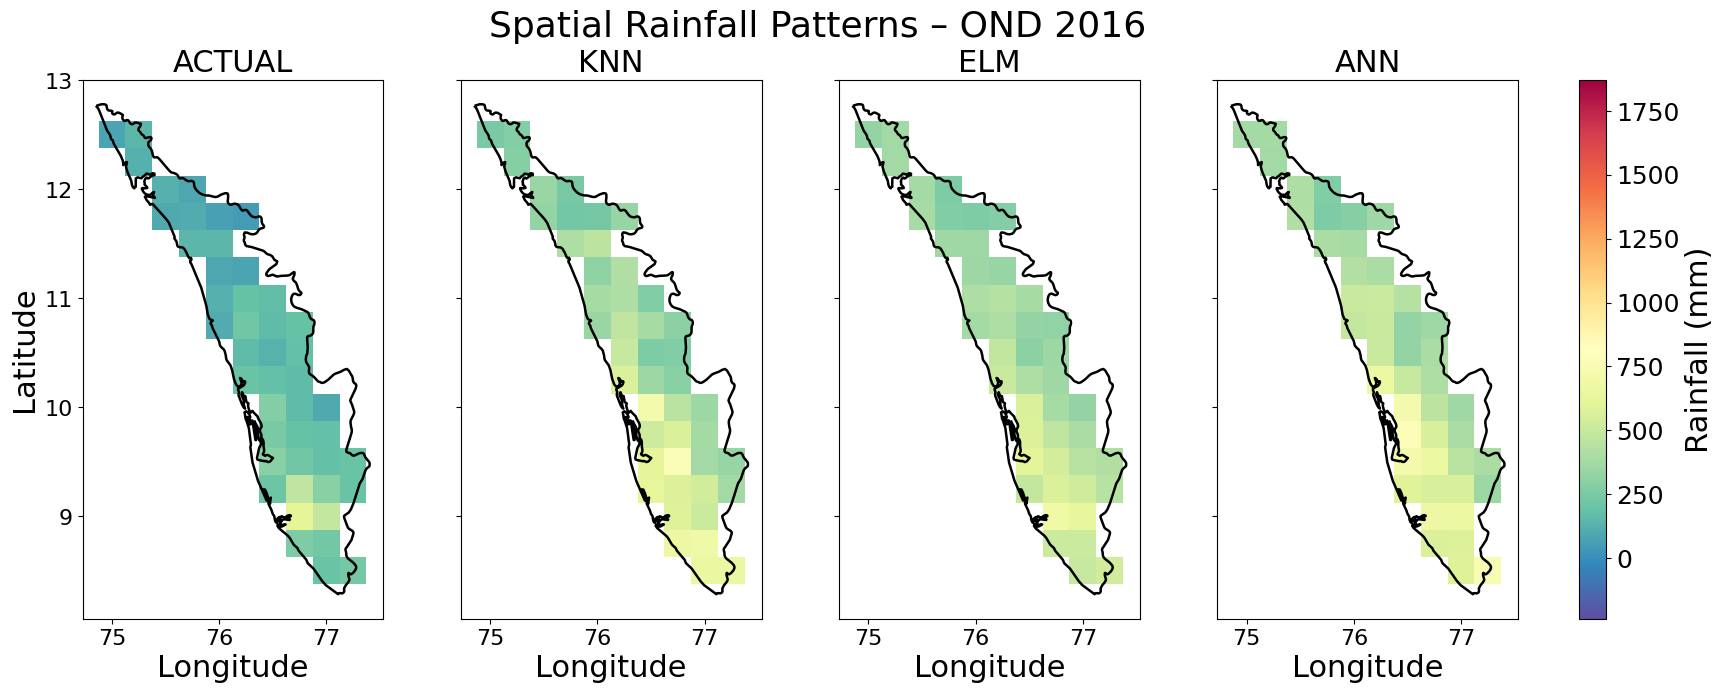

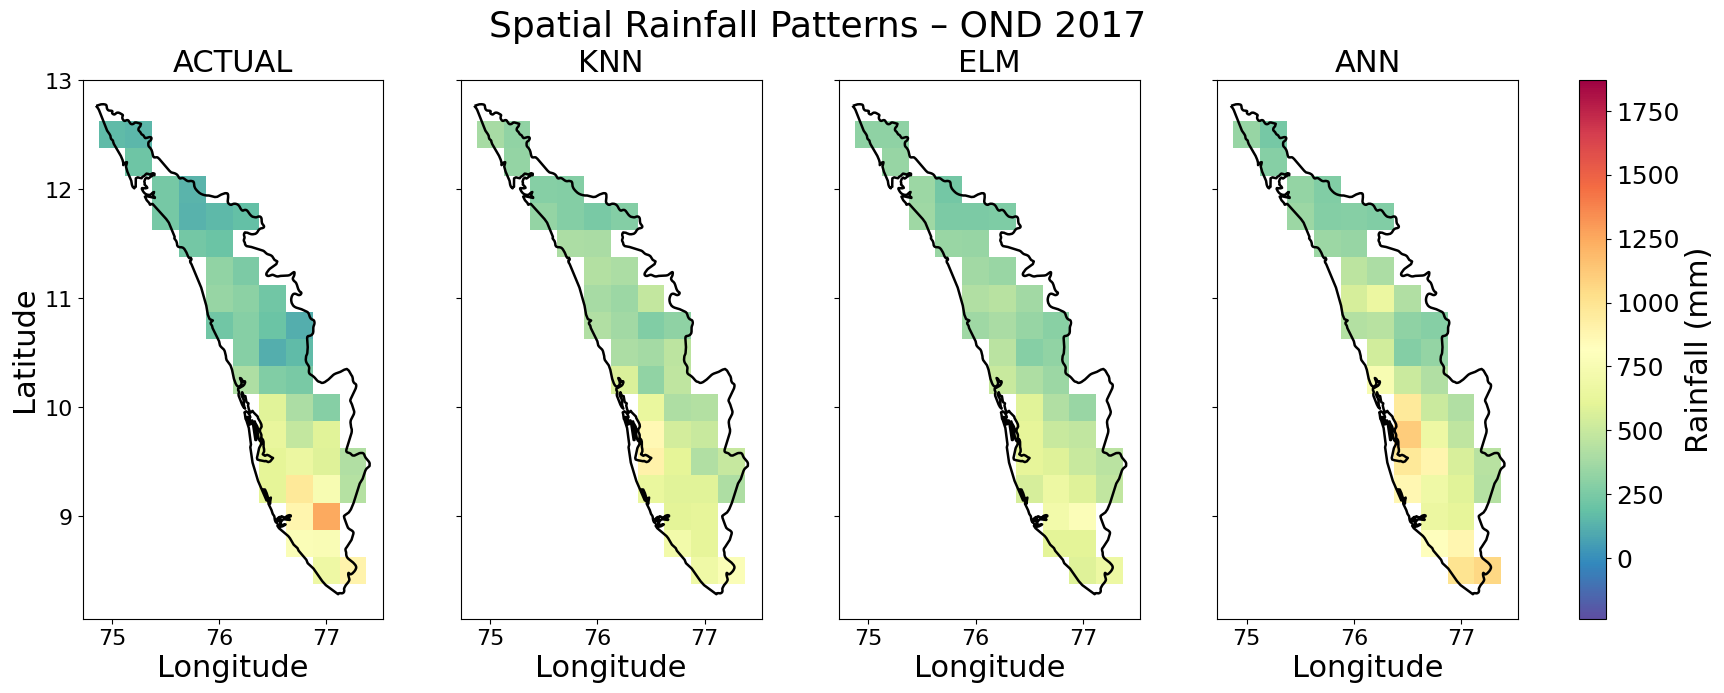

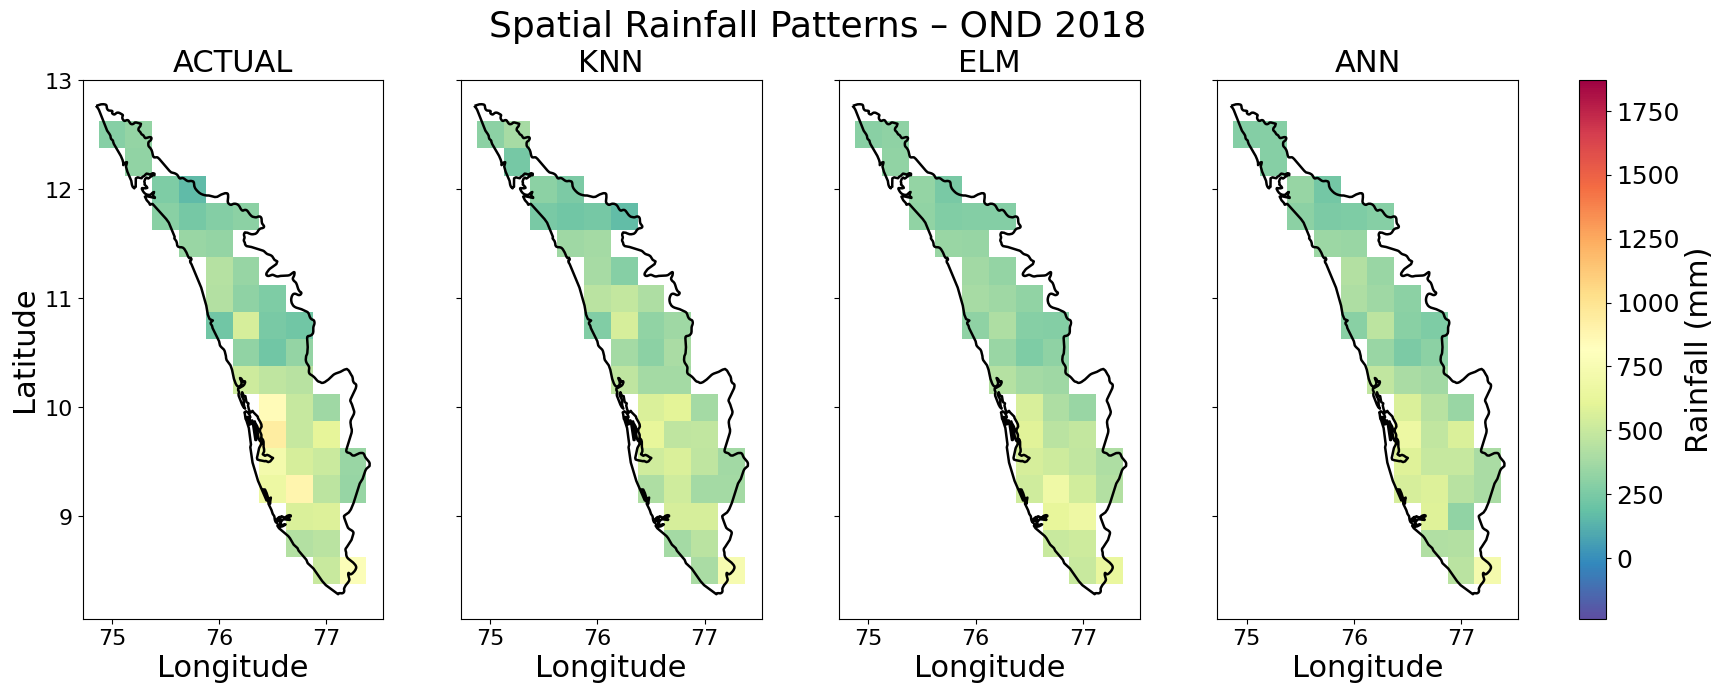

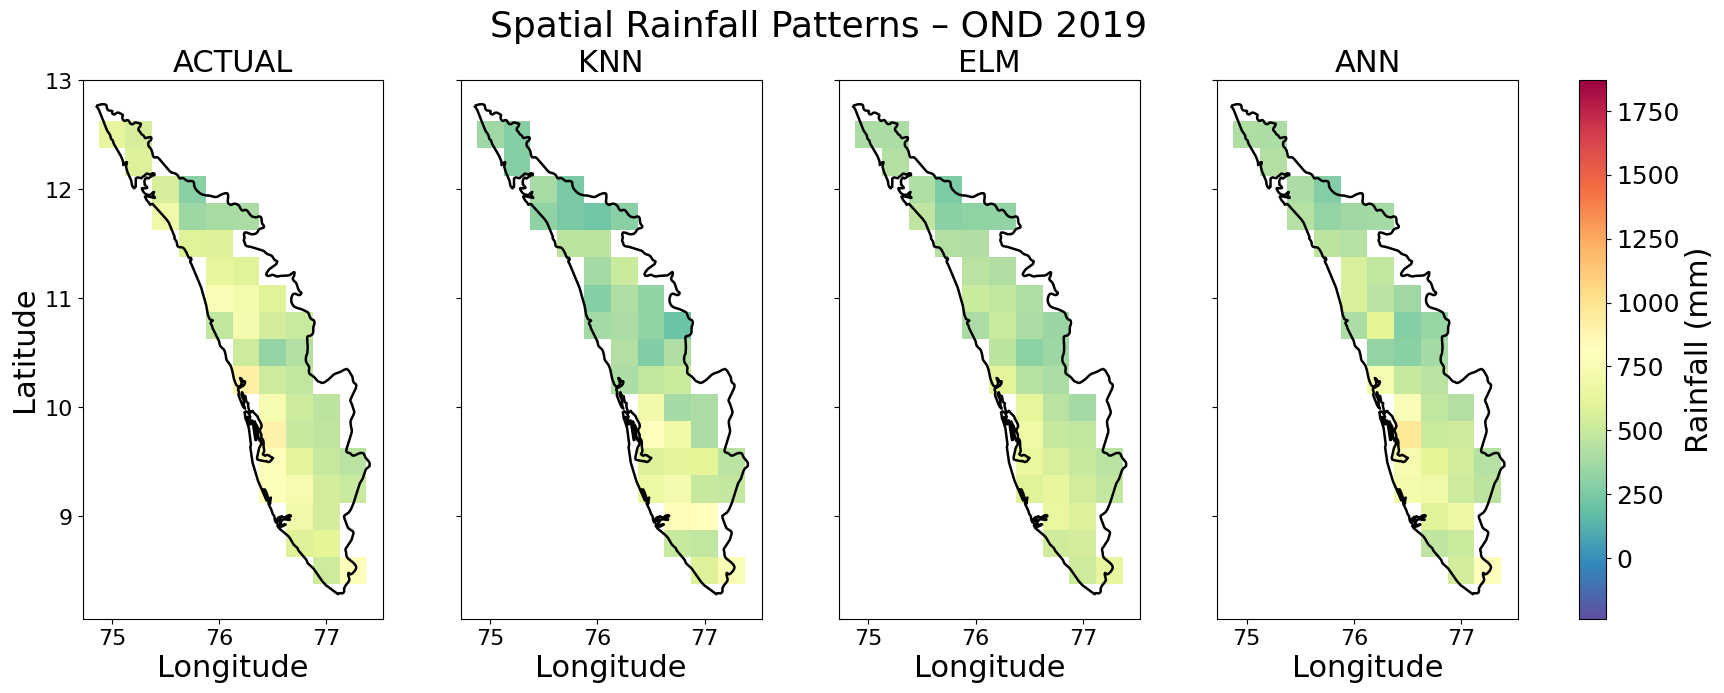

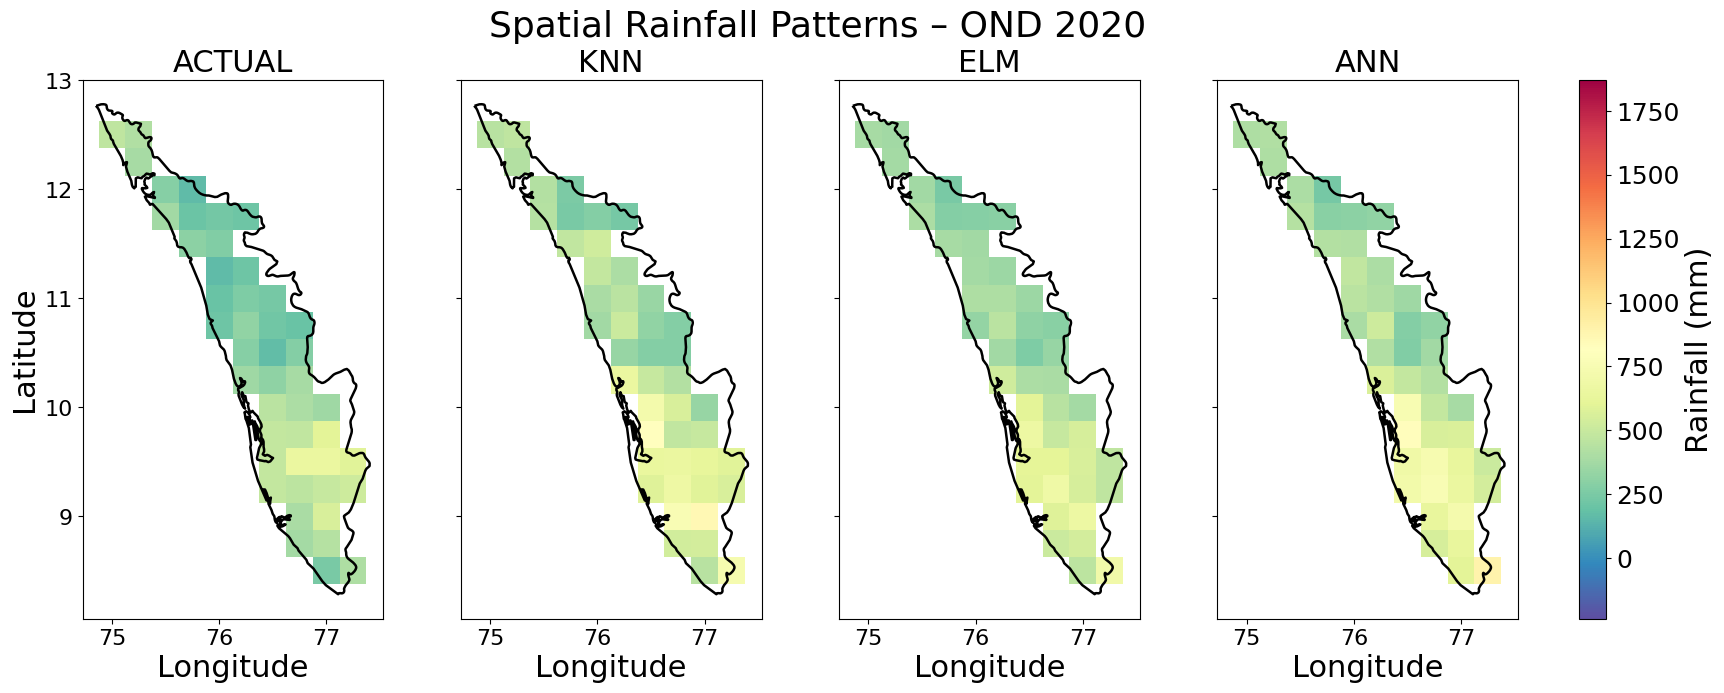

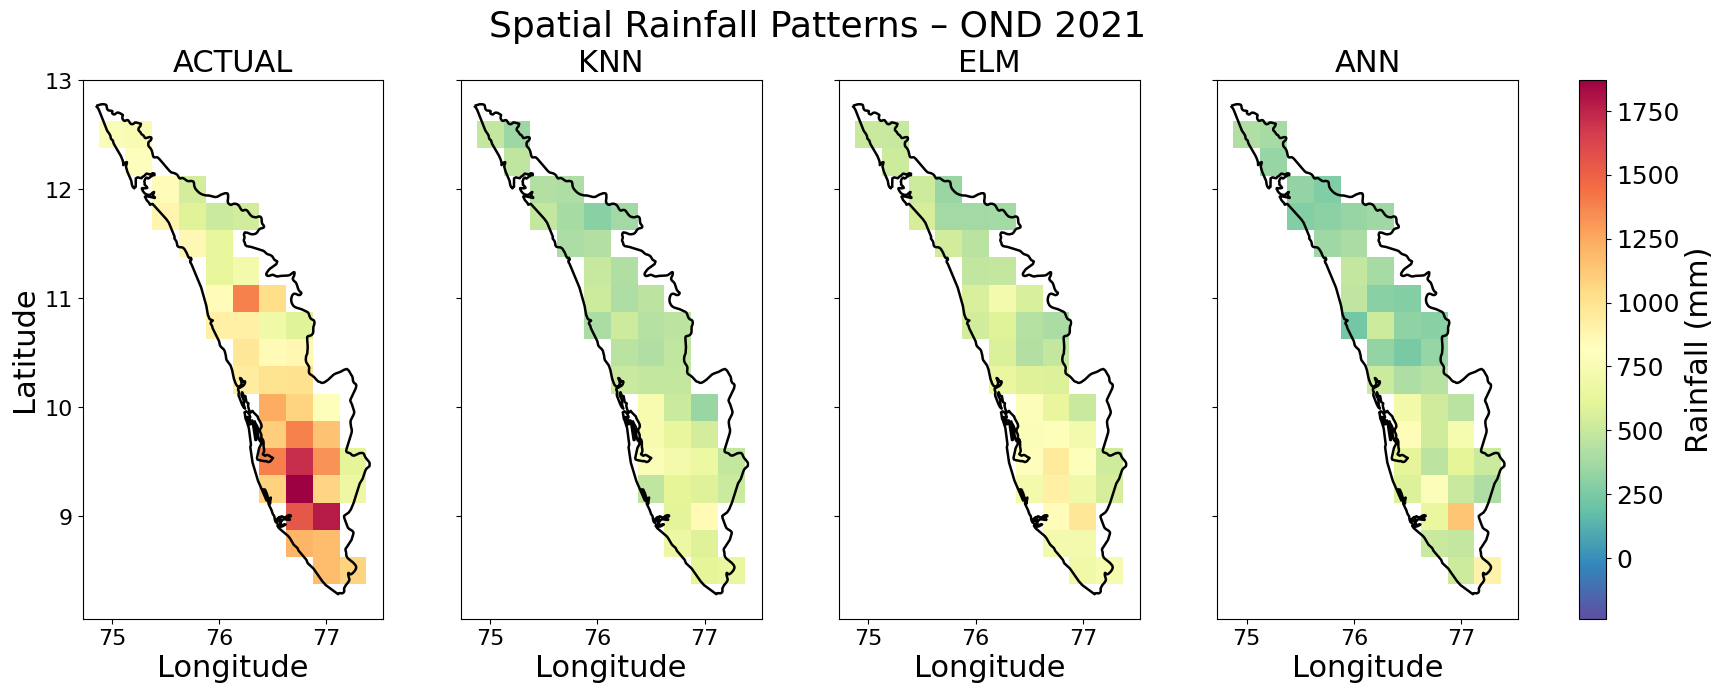

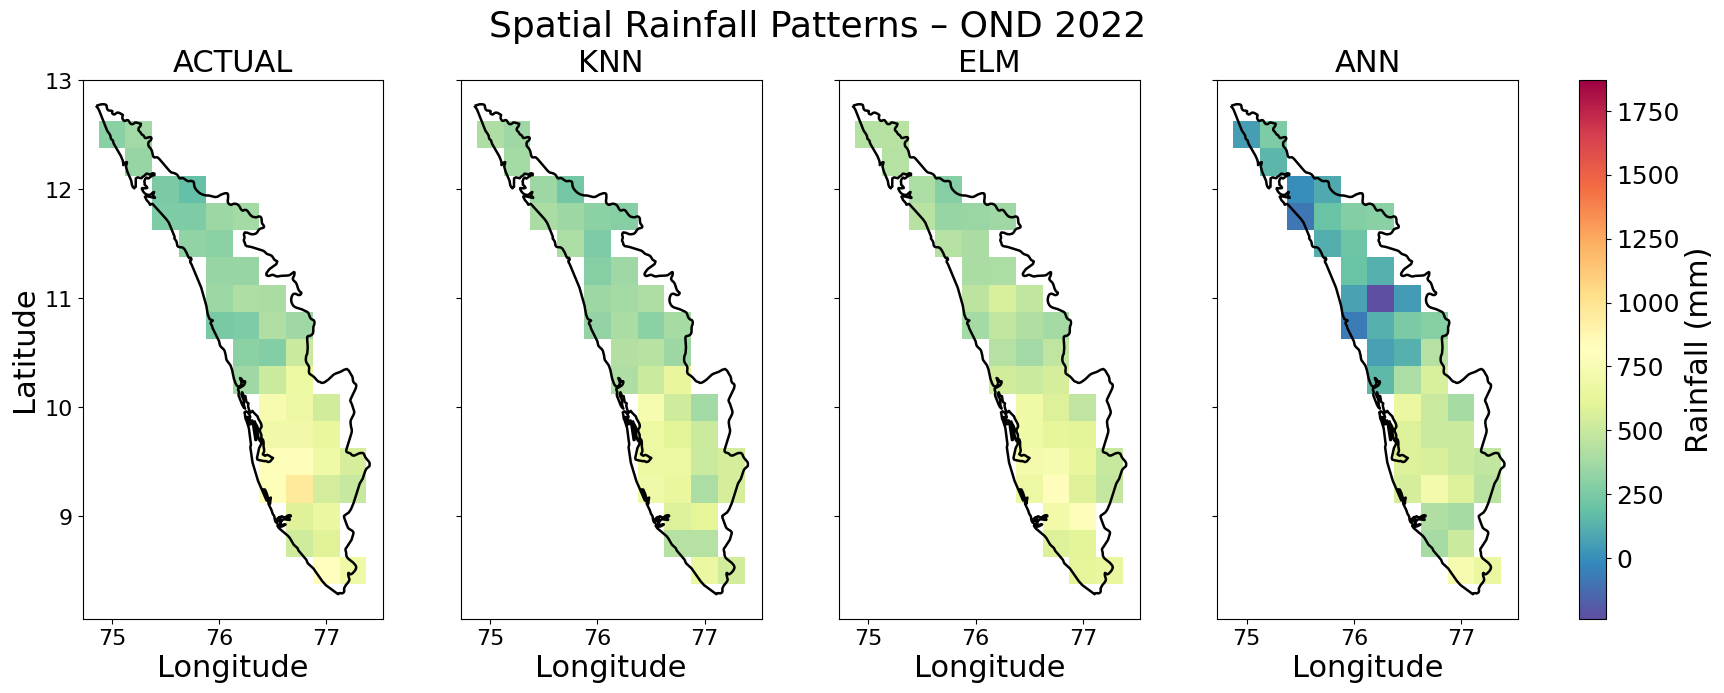

In [20]:
 # Visualizations
import geopandas as gpd

shp_path = r"ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"

india_states = gpd.read_file(shp_path)

kerala_shape = india_states[
    (india_states["admin"] == "India") &
    (india_states["name"] == "Kerala")
].to_crs(epsg=4326)
print("\nGenerating visualizations...")
visualize_results(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)
visualize_spatial_predictions(
    y_test_meta,
    y_true_orig,
    y_pred_knn_orig,
    y_pred_elm_orig,
    y_pred_ann_orig,
    kerala_shape
    
)



In [ ]:
def visualize_spatial_error(test_meta_df, y_true, y_pred_knn, y_pred_elm, y_pred_ann):

    results_df = test_meta_df.copy()

    # ACTUAL rainfall at YEAR = t
    results_df['ACTUAL'] = y_true

    # Predictions originally correspond to the SAME index,
    # but we want prediction(t-1) vs actual(t)
    results_df['KNN_PRED'] = y_pred_knn
    results_df['ELM_PRED'] = y_pred_elm
    results_df['ANN_PRED'] = y_pred_ann

    # 🔑 Create shifted prediction year
    results_df['PRED_YEAR'] = results_df['YEAR'] - 1
        # Split actuals and predictions
    actual_df = results_df[['YEAR', 'LATITUDE', 'LONGITUDE', 'ACTUAL']]

    pred_df = results_df[['PRED_YEAR', 'LATITUDE', 'LONGITUDE',
                           'KNN_PRED', 'ELM_PRED', 'ANN_PRED']].rename(
        columns={'PRED_YEAR': 'YEAR'}
    )

    # Merge so that:
    # ACTUAL(YEAR=t) aligns with PRED(YEAR=t) coming from t-1
    merged_df = pd.merge(
        actual_df,
        pred_df,
        on=['YEAR', 'LATITUDE', 'LONGITUDE'],
        how='inner'
    )
    merged_df['KNN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['KNN_PRED'])
    merged_df['ELM_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ELM_PRED'])
    merged_df['ANN_Error'] = np.abs(merged_df['ACTUAL'] - merged_df['ANN_PRED'])

    
    test_years = sorted(merged_df['YEAR'].unique())
    models = ['KNN_Error', 'ELM_Error', 'ANN_Error']

    
    vmin = merged_df[models].min().min()
    vmax = merged_df[models].max().max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    for year in test_years:
        year_df = merged_df[merged_df['YEAR'] == year]
        
        # yearly accuracy metrics
        print(f"\n--- Spatial Accuracy Metrics for {year} ---")
        mean_actual_for_year = year_df['ACTUAL'].mean()
        
        for model in ['KNN', 'ELM', 'ANN']:
            error_col = f'{model}_Error'
            mean_error = year_df[error_col].mean()
            max_error = year_df[error_col].max()
            
            # Calculate MAE percentage relative to the mean of actual values for THAT year
            mae_p = 100 * mean_error / mean_actual_for_year if mean_actual_for_year > 0 else 0
            
            print(f"  {model}:")
            print(f"    - Mean Absolute Error: {mean_error:.2f} mm ({mae_p:.1f}%)")
            print(f"    - Max Absolute Error:  {max_error:.2f} mm")
        

        
        

In [ ]:
visualize_spatial_error(y_test_meta, y_true_orig, y_pred_knn_orig, y_pred_elm_orig, y_pred_ann_orig)



--- Spatial Accuracy Metrics for 2011 ---
  KNN:
    - Mean Absolute Error: 314.64 mm (18.0%)
    - Max Absolute Error:  1086.02 mm
  ELM:
    - Mean Absolute Error: 262.34 mm (15.0%)
    - Max Absolute Error:  895.37 mm
  ANN:
    - Mean Absolute Error: 337.72 mm (19.3%)
    - Max Absolute Error:  1130.68 mm

--- Spatial Accuracy Metrics for 2012 ---
  KNN:
    - Mean Absolute Error: 370.63 mm (28.6%)
    - Max Absolute Error:  1232.28 mm
  ELM:
    - Mean Absolute Error: 300.79 mm (23.2%)
    - Max Absolute Error:  1187.07 mm
  ANN:
    - Mean Absolute Error: 230.17 mm (17.7%)
    - Max Absolute Error:  1234.62 mm

--- Spatial Accuracy Metrics for 2013 ---
  KNN:
    - Mean Absolute Error: 540.07 mm (24.3%)
    - Max Absolute Error:  1778.61 mm
  ELM:
    - Mean Absolute Error: 403.22 mm (18.2%)
    - Max Absolute Error:  1024.99 mm
  ANN:
    - Mean Absolute Error: 368.71 mm (16.6%)
    - Max Absolute Error:  1392.21 mm

--- Spatial Accuracy Metrics for 2014 ---
  KNN:
    - Mean A